# 📊 Machine Learning Task: Customer Churn Prediction (Classification)

---

## 🧠 Problem Statement

Customer churn is a major concern for businesses, especially in industries like telecom, banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.

In this project, the goal is to build a **Machine Learning classification model** that predicts whether a customer will leave the company (**Churn: Yes/No**) based on various features.

### 📌 Features Considered:
- Customer Age  
- Gender  
- Tenure  
- Monthly Charges  
- Total Charges  
- Contract Type  
- Payment Method  
- Internet Service  
- Tech Support  
- Online Security  
- Customer Support Calls  

---

## 🎯 Objective

The objective of this task is to:

- Understand and explore the customer dataset  
- Perform data preprocessing (handling missing values, duplicates, and outliers)  
- Conduct Exploratory Data Analysis (EDA)  
- Apply encoding techniques for categorical variables  
- Perform feature scaling  
- Train multiple classification algorithms  
- Evaluate models using classification metrics  
- Perform cross-validation and hyperparameter tuning  
- Select the best-performing model  

---

# 📋 Project Workflow: Customer Churn Prediction

---

## 🔷 STEP 1 — Problem Understanding
- **Goal:** Predict whether a telecom customer will churn (Yes/No) — a binary classification problem.
- **Target Variable:** `Churn` (1 = Left, 0 = Stayed)
- **Features Used:** Customer Age, Gender, Tenure, Monthly Charges, Total Charges, Contract Type, Payment Method, Internet Service, Tech Support, Online Security, Customer Support Calls.

---

## 🔷 STEP 2 — Library Imports & Setup
- Installed: `xgboost`, `imbalanced-learn`
- Imported core libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`
- Imported ML tools: `sklearn` (preprocessing, model selection, metrics), `xgboost`, `imblearn`
- Suppressed warnings for clean output.

---

## 🔷 STEP 3 — Data Loading & Initial Inspection
- Loaded dataset: `telecom_churn_data.csv`
- Inspected:
  - Shape (rows × columns)
  - Data types of each column
  - Summary statistics (`describe()`)
  - Missing values (`isnull().sum()`)
  - Duplicate rows

---

## 🔷 STEP 4 — Data Preprocessing (Cleaning)
- **Dropped** `customerID` — non-predictive identifier.
- **Fixed** `TotalCharges`: coerced spaces/blanks to `NaN` using `pd.to_numeric(..., errors='coerce')`.
- **Imputed missing values:**
  - `gender`, `PaperlessBilling` → filled with **mode** (categorical)
  - `MonthlyCharges`, `TotalCharges` → filled with **median** (numerical)
- **Removed duplicate rows** using `drop_duplicates()`.
- **Encoded target:** `Churn` mapped → `Yes: 1`, `No: 0`.

---

## 🔷 STEP 5 — Exploratory Data Analysis (EDA)

### Univariate Analysis
- Plotted **histograms with KDE** for numerical features: `tenure`, `MonthlyCharges`, `TotalCharges`.
- Plotted **count plots** for categorical features: `gender`, `Contract`, `InternetService`, `PaymentMethod`, `TechSupport`.

### Bivariate Analysis
- **Churn rate by category:** Bar plots for `Contract`, `InternetService`, `TechSupport` — identified month-to-month contracts and no-tech-support as high-churn segments.
- **Numerical vs Churn:** Box plots for `tenure`, `MonthlyCharges`, `TotalCharges` — lower tenure and higher charges correlated with churn.

---

## 🔷 STEP 6 — Correlation Analysis & Outlier Handling
- **Correlation Heatmap:** Label-encoded all object columns temporarily → plotted heatmap to identify feature relationships with `Churn`.
- **Outlier Treatment:** Applied **IQR clipping** (1.5×IQR rule) on `tenure`, `MonthlyCharges`, `TotalCharges` to cap extreme values without dropping rows.

---

## 🔷 STEP 7 — Feature Encoding & Scaling
- **Label Encoding** for binary categorical columns: `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`.
- **One-Hot Encoding** (`get_dummies`, `drop_first=True`) for multi-class columns: `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaymentMethod`.
- **StandardScaler** applied to all features → zero mean, unit variance (important for distance-based models like KNN and SVC).

---

## 🔷 STEP 8 — Train-Test Split & Class Imbalance Handling
- **80/20 stratified split** (`train_test_split` with `stratify=y`) to preserve class distribution.
- Applied **SMOTE (Synthetic Minority Over-sampling Technique)** on training data only to balance the churn vs non-churn class ratio.
  - ⚠️ SMOTE was applied **after** splitting to prevent data leakage.

---

## 🔷 STEP 9 — Model Training & Baseline Comparison
Trained **7 classification models** on SMOTE-balanced training data:

| Model | Notes |
|---|---|
| Logistic Regression | Linear baseline |
| K-Nearest Neighbors | Distance-based |
| Decision Tree | Rule-based |
| Random Forest | Ensemble (bagging) |
| Support Vector Classifier (SVC) | Margin-based |
| Gradient Boosting | Ensemble (boosting) |
| XGBoost | Optimized boosting |

- Evaluated all models using: **Accuracy, Precision, Recall, F1-Score, ROC-AUC**
- Results sorted by **ROC-AUC** (best metric for imbalanced classification).

---

## 🔷 STEP 10 — Hyperparameter Tuning (Best Model: Gradient Boosting)
- Selected **Gradient Boosting** as the best baseline model.
- Tuned using **RandomizedSearchCV** (15 iterations, 3-fold CV, `scoring='f1'`):
  - Hyperparameters searched: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `min_samples_leaf`
- **Custom probability threshold (0.40)** used instead of default 0.50 → improves **Recall** for the churn class (catching more actual churners is business-critical).
- **3-fold Cross-Validation** on full scaled data → reported mean ± std ROC-AUC for generalization check.
- Plotted **normalized Confusion Matrix** with actual counts and percentages.

---

## 🔷 STEP 11 — Feature Importance & Final Summary
- Extracted **Top 15 Feature Importances** from the tuned Gradient Boosting model → horizontal bar chart.
- Printed a **final comparison table** of all 7 models + the tuned best model.

### 🏆 Top Churn Drivers Identified:
| Feature | Insight |
|---|---|
| Tenure | Short-tenure customers churn most |
| Monthly Charges | Higher charges → higher churn risk |
| Contract Type | Month-to-month = highest churn rate |
| Tech Support | No support → significantly more churn |
| Total Charges | Low total = newer, high-risk customers |

### 💼 Business Recommendations:
- Offer **long-term contract discounts** to new customers.
- **Bundle tech support** in base plans.
- Flag customers with **tenure < 12 months** for proactive retention calls.
- Introduce **loyalty pricing** for customers spending above $70/month.

---

## ✅ Final Model Selected
**Tuned Gradient Boosting Classifier** with a custom threshold of **0.40**  
→ Optimized for higher **Recall** to minimize missed churners, with strong **ROC-AUC** and **F1-Score**.

In [1]:
!pip install xgboost imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('telecom_churn_data.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (7043, 21)

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Summary Statistics:
        SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7041.000000
mean        0.162147    32.371149       64.749581
std         0.368612    24.559481       30.085731
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.3

In [3]:
# Drop customerID (not a feature)
df.drop(columns=['customerID'], inplace=True)

# TotalCharges has spaces — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['gender'].fillna(df['gender'].mode()[0], inplace=True)
df['PaperlessBilling'].fillna(df['PaperlessBilling'].mode()[0], inplace=True)
df['MonthlyCharges'].fillna(df['MonthlyCharges'].median(), inplace=True)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Cleaned shape:", df.shape)
print("Missing after fix:\n", df.isnull().sum())

Cleaned shape: (7021, 20)
Missing after fix:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


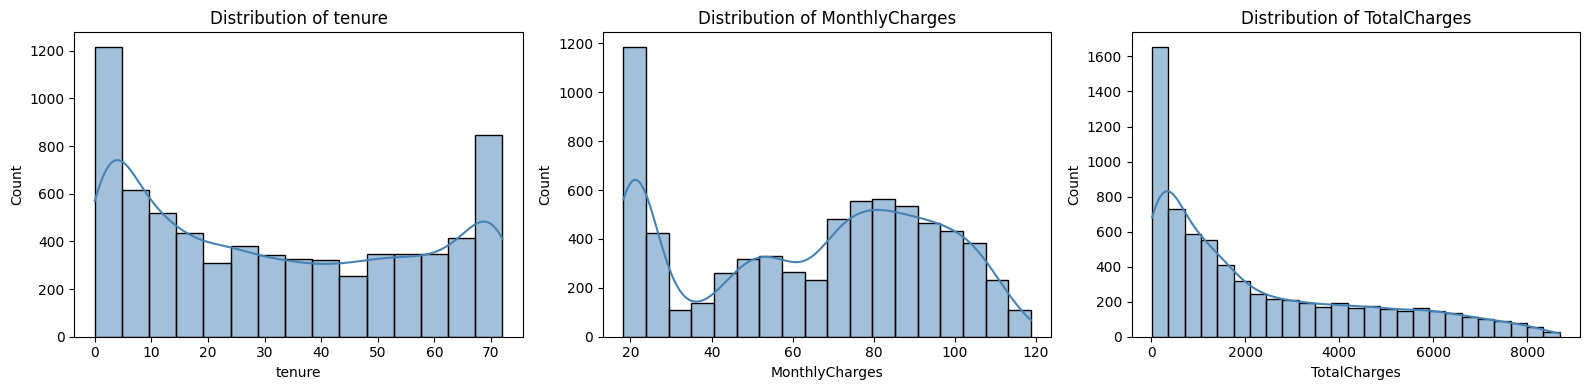

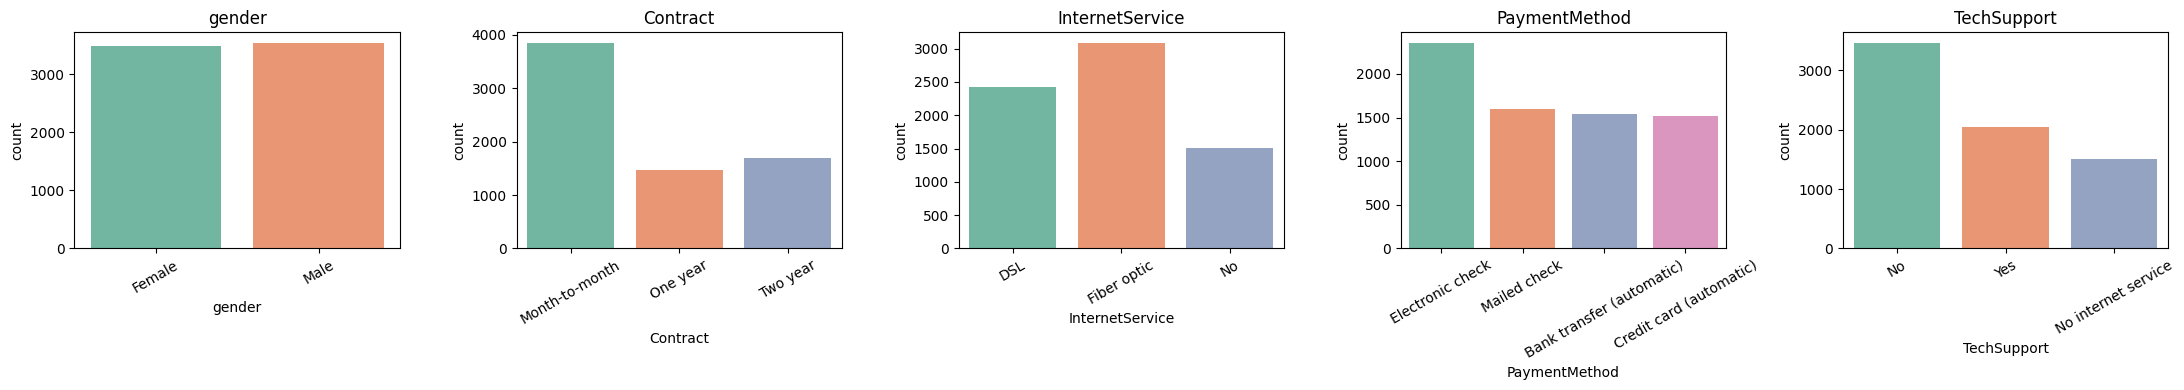

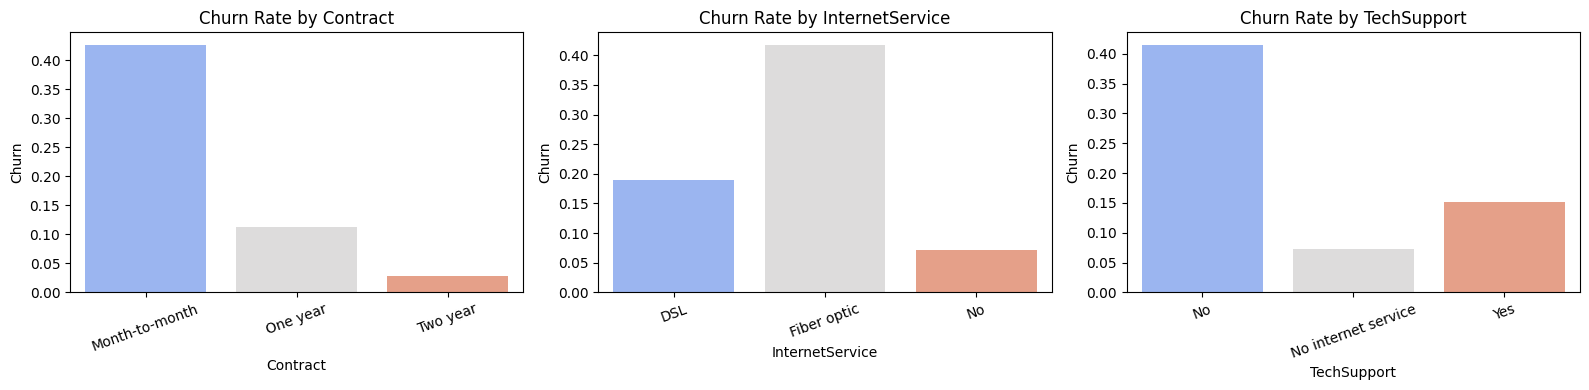

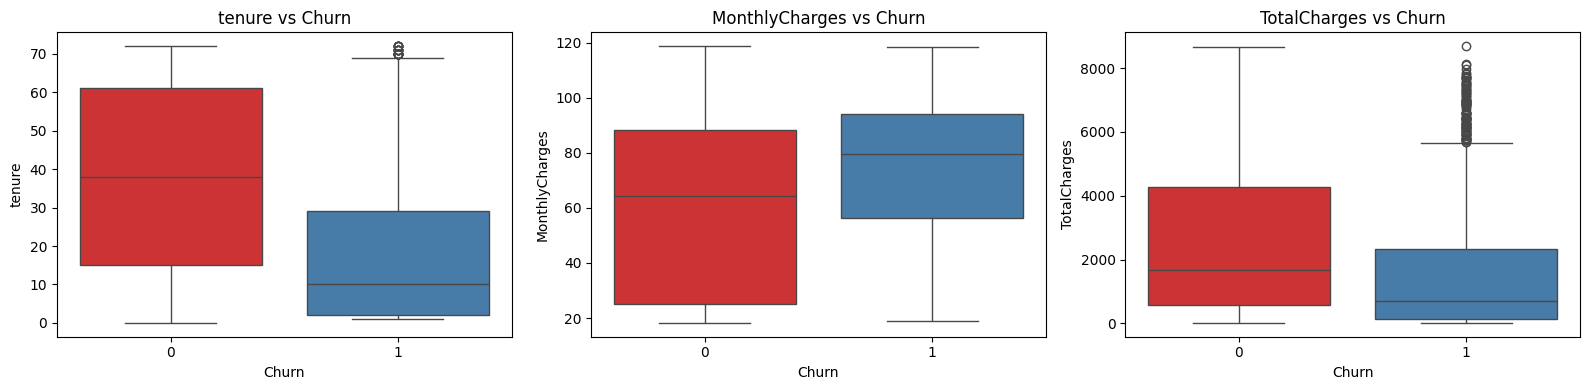

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Categorical feature counts
cat_cols = ['gender', 'Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax, palette='Set2', hue=col, legend=False)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Bivariate: Churn vs categorical
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Contract', 'InternetService', 'TechSupport']):
    ct = df.groupby(col)['Churn'].mean().reset_index()
    sns.barplot(data=ct, x=col, y='Churn', ax=ax, palette='coolwarm', hue=col, legend=False)
    ax.set_title(f'Churn Rate by {col}')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# Bivariate: Churn vs numerical
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax, palette='Set1', hue='Churn', legend=False)
    ax.set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

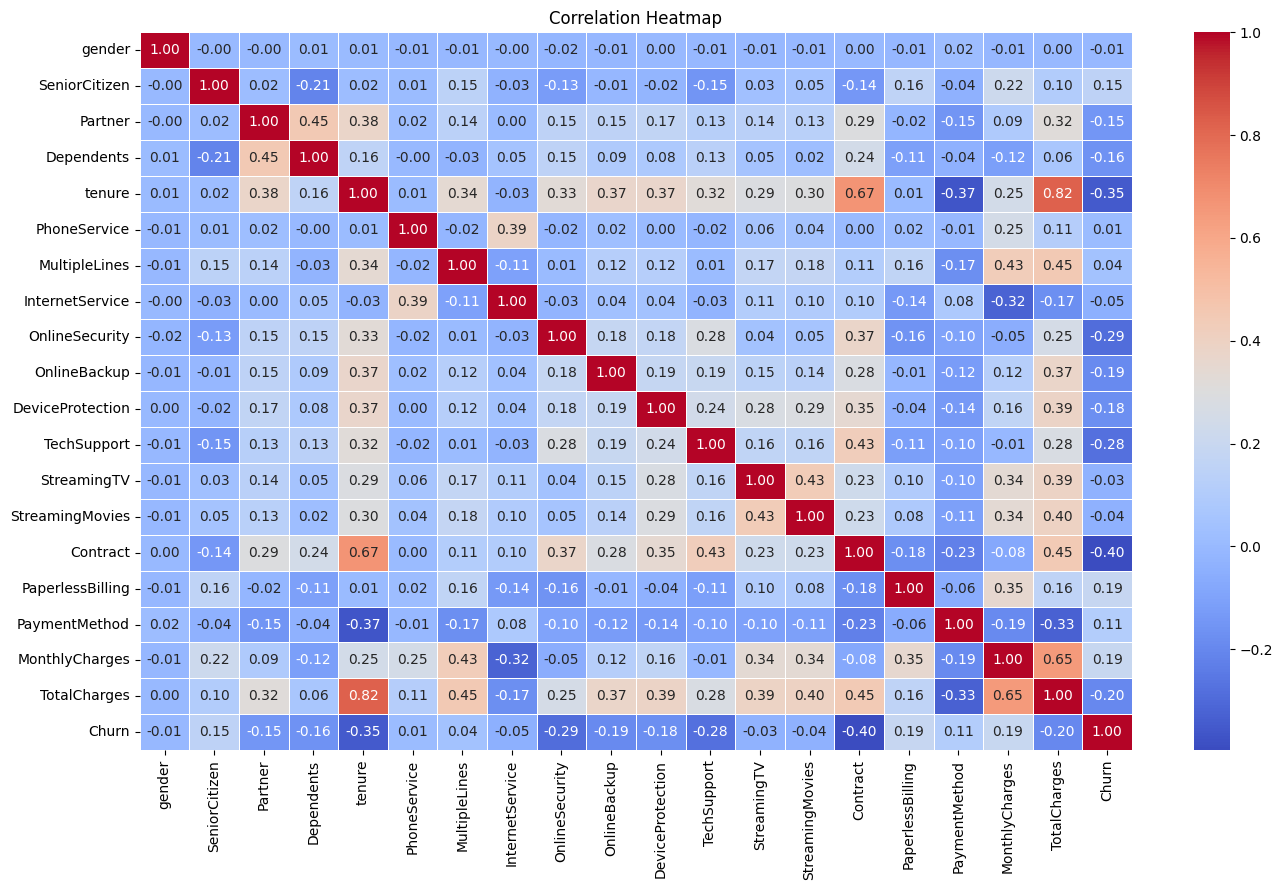

Outliers clipped for numerical columns.


In [5]:
# Encode binary categoricals temporarily for correlation
df_corr = df.copy()
for col in df_corr.select_dtypes('object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(14, 9))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Outlier handling via IQR clipping
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print("Outliers clipped for numerical columns.")

In [6]:
# Label encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-Hot encode multi-class columns
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Class distribution:\n", y.value_counts())

Feature matrix shape: (7021, 30)
Class distribution:
 Churn
0    5164
1    1857
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())
print("Test set size:", X_test.shape)

Before SMOTE: {0: 4131, 1: 1485}
After SMOTE:  {1: 4131, 0: 4131}
Test set size: (1405, 30)


In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVC': SVC(probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    }

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(results_df.to_string())

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Gradient Boosting      0.7829     0.5770  0.6747    0.6221   0.8405
Logistic Regression    0.7416     0.5081  0.7608    0.6093   0.8401
SVC                    0.7701     0.5511  0.7097    0.6204   0.8253
Random Forest          0.7751     0.5795  0.5484    0.5635   0.8184
XGBoost                0.7701     0.5675  0.5538    0.5605   0.8166
KNN                    0.7011     0.4604  0.7500    0.5706   0.7716
Decision Tree          0.7288     0.4891  0.5403    0.5134   0.6683


Best Params: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.05}

Threshold: 0.4
Tuned Gradient Boosting → Accuracy: 0.7616 | Precision: 0.5352 | Recall: 0.7554 | F1: 0.6265 | ROC-AUC: 0.8410
CV ROC-AUC: 0.8452 ± 0.0066


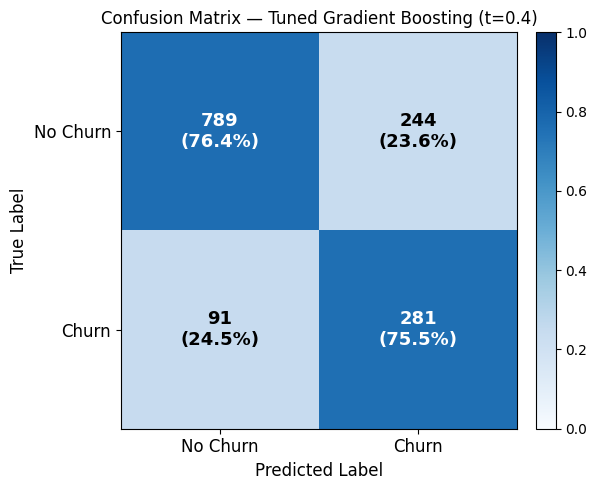

In [9]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Better params focused on generalization
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'min_samples_leaf': [1, 5, 10]
}

gb = GradientBoostingClassifier(random_state=42)
random_search = RandomizedSearchCV(gb, param_grid, n_iter=15, cv=3,
                                   scoring='f1', random_state=42, n_jobs=-1)
random_search.fit(X_train_sm, y_train_sm)

best_model = random_search.best_estimator_
print("Best Params:", random_search.best_params_)

y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Lower threshold to improve recall on churn class
threshold = 0.40
y_pred_best = (y_prob_best >= threshold).astype(int)

print(f"\nThreshold: {threshold}")
print(f"Tuned Gradient Boosting → Accuracy: {accuracy_score(y_test, y_pred_best):.4f} | "
      f"Precision: {precision_score(y_test, y_pred_best):.4f} | "
      f"Recall: {recall_score(y_test, y_pred_best):.4f} | "
      f"F1: {f1_score(y_test, y_pred_best):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

cv_scores = cross_val_score(best_model, X_scaled, y, cv=3, scoring='roc_auc')
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['No Churn', 'Churn'], fontsize=12)
ax.set_yticklabels(['No Churn', 'Churn'], fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — Tuned Gradient Boosting (t={threshold})', fontsize=12)

thresh = 0.5
for i in range(2):
    for j in range(2):
        pct = cm_norm[i, j] * 100
        color = "white" if cm_norm[i, j] > thresh else "black"
        ax.text(j, i, f"{cm[i, j]}\n({pct:.1f}%)", ha='center', va='center',
                fontsize=13, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

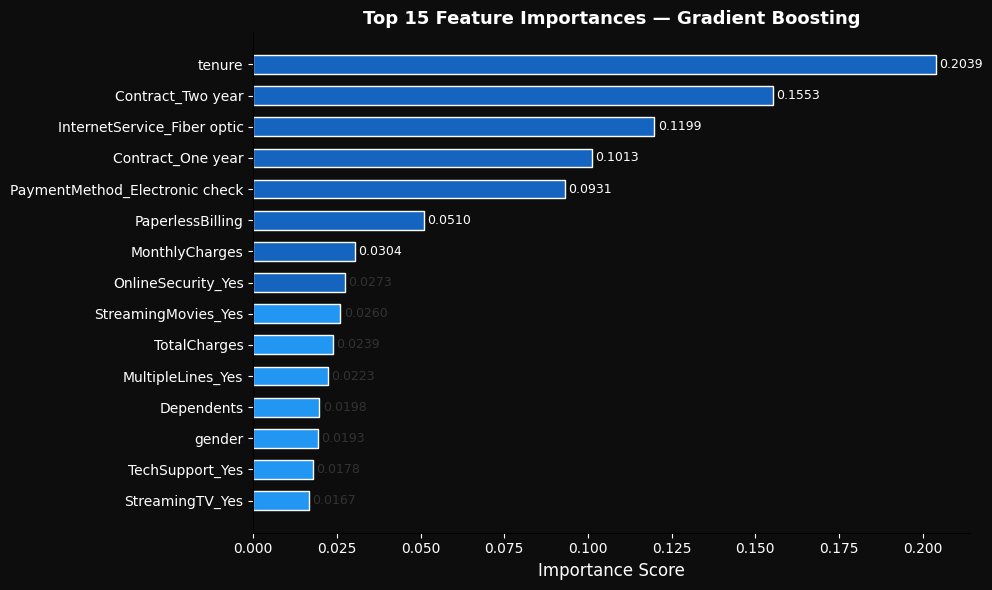

MODEL                         ACC    PREC  RECALL      F1     AUC
Gradient Boosting          0.7829   0.577  0.6747  0.6221  0.8405 ✅
Logistic Regression        0.7416  0.5081  0.7608  0.6093  0.8401
SVC                        0.7701  0.5511  0.7097  0.6204  0.8253
Random Forest              0.7751  0.5795  0.5484  0.5635  0.8184
XGBoost                    0.7701  0.5675  0.5538  0.5605  0.8166
KNN                        0.7011  0.4604    0.75  0.5706  0.7716
Decision Tree              0.7288  0.4891  0.5403  0.5134  0.6683

BEST MODEL (Tuned):           ACC    PREC  RECALL      F1     AUC
----------------------------------------------------------------------
Gradient Boosting          0.7616  0.5352  0.7554  0.6265  0.8410

╔══════════════════════════════════════════════════════════════════╗
║                     FINAL INSIGHTS                              ║
╠══════════════════════════════════════════════════════════════════╣
║  TOP CHURN DRIVERS:                                      

In [10]:
# Feature Importance
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
top15 = feat_imp.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3' if v < top15.median() else '#1565C0' for v in top15]
bars = ax.barh(top15.index, top15.values, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, top15.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, color='white' if val > top15.median() else '#333')

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Feature Importances — Gradient Boosting', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#0d0d0d')
fig.patch.set_facecolor('#0d0d0d')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.title.set_color('white')
plt.tight_layout()
plt.show()

# Final Comparison Table
print("=" * 70)
print(f"{'MODEL':<25} {'ACC':>7} {'PREC':>7} {'RECALL':>7} {'F1':>7} {'AUC':>7}")
print("=" * 70)
for model_name, metrics in sorted(results.items(), key=lambda x: x[1]['ROC-AUC'], reverse=True):
    marker = " ✅" if model_name == 'Gradient Boosting' else ""
    print(f"{model_name:<25} {metrics['Accuracy']:>7} {metrics['Precision']:>7} "
          f"{metrics['Recall']:>7} {metrics['F1 Score']:>7} {metrics['ROC-AUC']:>7}{marker}")
print("=" * 70)

# Tuned model final scores
print(f"\n{'BEST MODEL (Tuned):':<25} "
      f"{'ACC':>7} {'PREC':>7} {'RECALL':>7} {'F1':>7} {'AUC':>7}")
print("-" * 70)
print(f"{'Gradient Boosting':<25} "
      f"{accuracy_score(y_test, y_pred_best):>7.4f} "
      f"{precision_score(y_test, y_pred_best):>7.4f} "
      f"{recall_score(y_test, y_pred_best):>7.4f} "
      f"{f1_score(y_test, y_pred_best):>7.4f} "
      f"{roc_auc_score(y_test, y_prob_best):>7.4f}")
print("=" * 70)

print("""
╔══════════════════════════════════════════════════════════════════╗
║                     FINAL INSIGHTS                              ║
╠══════════════════════════════════════════════════════════════════╣
║  TOP CHURN DRIVERS:                                             ║
║  • Tenure          → Short-tenure customers churn most          ║
║  • Monthly Charges → Higher charges = higher churn risk         ║
║  • Contract Type   → Month-to-month = highest churn             ║
║  • Tech Support    → No support = significantly more churn      ║
║  • Total Charges   → Low total = newer, high-risk customers     ║
╠══════════════════════════════════════════════════════════════════╣
║  BUSINESS RECOMMENDATIONS:                                      ║
║  • Offer long-term contract discounts to new customers          ║
║  • Bundle tech support in base plans                            ║
║  • Flag customers with tenure < 12 months for retention calls   ║
║  • Introduce loyalty pricing above $70/month spend              ║
╚══════════════════════════════════════════════════════════════════╝
""")

In [11]:
# save the model for streamlit deployment
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

# ── 1. Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv('telecom_churn_data.csv')

# ── 2. Preprocessing ──────────────────────────────────────────────────────────
df.drop(columns=['customerID'], inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['gender'].fillna(df['gender'].mode()[0], inplace=True)
df['PaperlessBilling'].fillna(df['PaperlessBilling'].mode()[0], inplace=True)
df['MonthlyCharges'].fillna(df['MonthlyCharges'].median(), inplace=True)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df.drop_duplicates(inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ── 3. Outlier clipping ───────────────────────────────────────────────────────
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# ── 4. Encoding ───────────────────────────────────────────────────────────────
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
label_encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Save column order (needed to align user input in the app)
feature_columns = [c for c in df.columns if c != 'Churn']

X = df[feature_columns]
y = df['Churn']

# ── 5. Scaling ────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 6. Train / Test split + SMOTE ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# ── 7. Hyperparameter tuning (matches notebook) ───────────────────────────────
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'min_samples_leaf': [1, 5, 10]
}

gb = GradientBoostingClassifier(random_state=42)
random_search = RandomizedSearchCV(
    gb, param_grid, n_iter=15, cv=3,
    scoring='f1', random_state=42, n_jobs=-1
)
random_search.fit(X_train_sm, y_train_sm)
best_model = random_search.best_estimator_
print("Best Params:", random_search.best_params_)

# ── 8. Save everything needed by the Streamlit app ───────────────────────────
artifacts = {
    'model': best_model,
    'scaler': scaler,
    'feature_columns': feature_columns,
    'label_encoders': label_encoders,
    'multi_cols': multi_cols,
    'threshold': 0.40
}

with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("\n✅ model_artifacts.pkl saved successfully!")
print(f"   Features : {len(feature_columns)}")
print(f"   Threshold: 0.40")

Best Params: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.05}

✅ model_artifacts.pkl saved successfully!
   Features : 30
   Threshold: 0.40
